# Snohomish Build Code

Steps:
1. Using an input manning geotiff, set values in the channel to a preset value
2. Validate files
3. Build sfincs grid
4. Build input files

## Intake Manning file

Optional, you can always just use your own manning file, but testing revealed some issues with the existing manning geotiff and to brush over it, I'll just set every channel value to 0.02 -- channel as defined by the 20m refinement polygon set, which is just the channels. 

In [1]:
import rasterio
from rasterio.features import geometry_mask
from rasterio.windows import Window
import geopandas as gpd
import numpy as np

parent_dir = '/home/cassandra/Snohomish/2026-05-14/'
input_manning_tif = "/home/cassandra/Snohomish/snohomish_manning_project_UPDATED.tif"
output_manning_tif = parent_dir + "snohomish_manning.tif"
channel_shapefile = parent_dir + "refine_20m.geojson"
channel_gdf = gpd.read_file(channel_shapefile)
channel_manning = 0.02  # value to assign inside polygons
chunk_size = 5*1024 

with rasterio.open(input_manning_tif) as src:

    # Transform polygon CRS if necessary
    if channel_gdf.crs != src.crs:
        channel_gdf = channel_gdf.to_crs(src.crs)
    channel_polygons = channel_gdf.geometry.values

    # Make new geotiff
    profile = src.profile.copy()
    with rasterio.open(output_manning_tif, "w", **profile) as dst:

        # For each chunk of data
        for row_off in range(0, src.height, chunk_size):
            for col_off in range(0, src.width, chunk_size):
                width = min(chunk_size, src.width - col_off)
                height = min(chunk_size, src.height - row_off)
                window = Window(col_off, row_off, width, height)
                data = src.read(1, window=window)

                # mask the contained points and overwrite
                transform = src.window_transform(window)
                mask = geometry_mask(
                    channel_polygons,
                    transform=transform,
                    invert=True,
                    out_shape=(height, width))
                data[mask] = channel_manning
                dst.write(data, 1, window=window)

## Build SFINCS input


### Imports

In [2]:
from hydromt_sfincs import SfincsModel

import os
import geopandas as gpd
import pandas as pd
import numpy as np
import xarray as xr

from shapely.geometry import Point

### Check Files

In [3]:
parent_dir = '/home/cassandra/Snohomish/2026-05-14/'
DEM_PATH = "/home/cassandra/Data/Snoh_DEM_composite/Snohomish_MosaicDEM_modded.tif"

manning_override = 0.02

required_files = {
    "DEM":               DEM_PATH,
    "manfile":           parent_dir + 'snohomish_manning.tif',
    "include":           parent_dir + "include.geojson",
    "offshore_boundary": parent_dir + "offshore_boundary.geojson",
    "refine_20m":        parent_dir + "refine_20m.geojson",
    "refine_10m":        parent_dir + "refine_10m.geojson",
    "levees":            parent_dir + "levees.geojson",
    "drainage":          parent_dir + "drainage.geojson",
    "obs":               parent_dir + "obs.geojson"
}

for rf in required_files:
    if not os.path.exists(required_files[rf]):
        print(required_files[rf], 'is missing!')
        sys.exit(1)

print("All required input files found.\n")

All required input files found.



### Load Geometries

In [4]:
include_gdf  = gpd.read_file(required_files['include'])
offshore_gdf = gpd.read_file(required_files['offshore_boundary'])
levees_gdf   = gpd.read_file(required_files['levees'])
drainage_gdf = gpd.read_file(required_files['drainage'])
obs_gdf      = gpd.read_file(required_files['obs'])

refine_specs = [
    (required_files['refine_20m'], 2),
    (required_files['refine_10m'], 3)]

refine_parts = []
for fpath, level in refine_specs:
    gdf = gpd.read_file(fpath)
    gdf = gdf[["geometry"]].copy()
    gdf["refinement_level"] = level
    refine_parts.append(gdf)

refinement_gdf = gpd.GeoDataFrame(
    pd.concat(refine_parts, ignore_index=True), crs=include_gdf.crs
)

elevation_list = [{"elevation": required_files['DEM']}]
roughness_list = [{"manning": required_files['manfile']}]

### 

In [5]:
sf = SfincsModel(root=parent_dir, mode="w+")

sf.quadtree_grid.create_from_region(
    region={"geom": include_gdf},
    res=80,
    crs=32610,
    rotated=False,
    refinement_polygons=refinement_gdf,
)

sf.quadtree_elevation.create(
    elevation_list=elevation_list,
    interp_method="linear",
    buffer_cells=1,
)

sf.quadtree_mask.create_active(
    include_polygon=include_gdf,
)

sf.quadtree_mask.create_boundary(
    btype="waterlevel",
    include_polygon=offshore_gdf,
    reset_bounds=True,
)

sf.quadtree_roughness.create(
    roughness_list=roughness_list,
    manning_land=manning_override,
    manning_sea=manning_override,
    rgh_lev_land=0,   # z = 0 m as land/sea boundary
)

sf.weirs.create(
    locations=levees_gdf,
    dep=DEM_PATH,   # sample crest elevation from DEM
    merge=False,
)

sf.drainage_structures.create(
    locations=drainage_gdf,
    merge=False,
)

sf.observation_points.create(
    locations=obs_gdf,
    merge=False,
)

No region component found in components.


Refining ...
Time elapsed : 20.91461205482483 s
Finding neighbors ...
Time elapsed : 0.056238651275634766 s
Setting neighbors left and below ...
Time elapsed : 0.6085164546966553 s
Getting uv points ...
Time elapsed : 0.2502894401550293 s
Making XUGrid ...
Got rid of duplicates in 1.1101 seconds
Made XUGrid in 0.0039 seconds


overwriting data source 'Snohomish_MosaicDEM_modded.tif' with provider user and version _UNSPECIFIED_.
overwriting data source 'Snohomish_MosaicDEM_modded.tif' with provider user and version _UNSPECIFIED_.
overwriting data source 'Snohomish_MosaicDEM_modded.tif' with provider user and version _UNSPECIFIED_.
Replacing mesh parameter: z
nodata value missing for /home/cassandra/Snohomish/2026-05-14/snohomish_manning.tif
overwriting data source 'Snohomish_MosaicDEM_modded.tif' with provider user and version _UNSPECIFIED_.


### Subgrid Table

In [6]:
%%capture cap 
# "Magic Command" to squash cell output

sf.quadtree_subgrid.create(
    elevation_list=elevation_list,
    roughness_list=roughness_list,
    manning_land=manning_override,
    manning_water=manning_override,
    manning_level=0.0, # z = 0 m as land/sea boundary
    nr_subgrid_pixels=20,
    nr_levels=20,
    write_dep_tif=False,
    write_man_tif=False,
    nrmax=2000,
)

### Save Files

In [7]:
sf.write()

Error writing variable manning: can only concatenate str (not "list") to str


## Sanity Checks

### Plot

(<Figure size 600x535.714 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS z map'}, xlabel='x [m] - WGS 84 / UTM zone 10N', ylabel='y [m]'>)

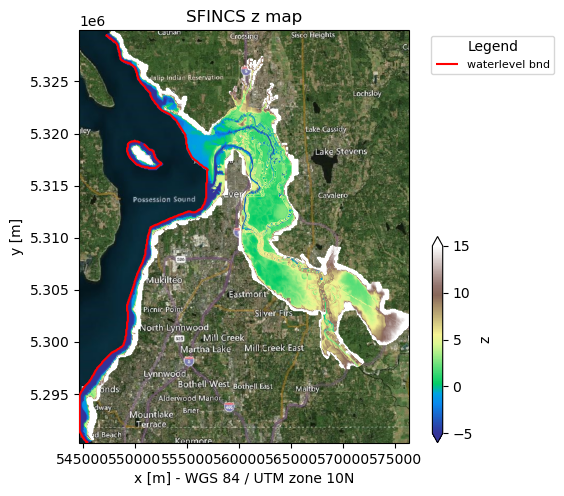

In [22]:
sf.plot_basemap(
    variable="elevation", plot_region=False, plot_geoms = False, plot_bounds=True, bmap="sat", vmin=-5, vmax=15,
)

(<Figure size 600x535.714 with 2 Axes>,
 <GeoAxes: title={'center': 'SFINCS manning map'}, xlabel='x [m] - WGS 84 / UTM zone 10N', ylabel='y [m]'>)

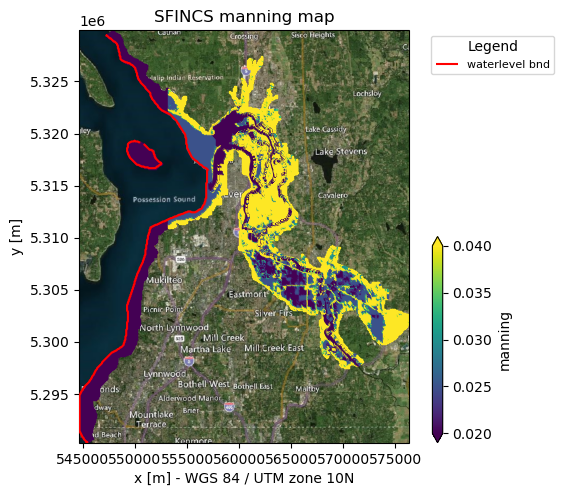

In [24]:
sf.plot_basemap(
    variable="manning", plot_region=False, plot_geoms = False, plot_bounds=True, 
    bmap="sat", vmin=0.02, vmax=0.04,
)

## Export sfincs.nc to xugrid compliant nc, for GIS

In [9]:
import xugrid as xu

x_qtr = xu.load_dataset(parent_dir + 'sfincs.nc')
x_qtr.z.ugrid.to_netcdf(parent_dir + 'qtr_z.nc')
x_qtr.mask.astype(float).ugrid.to_netcdf(parent_dir + 'qtr_mask.nc')

Nice to see things in GIS:

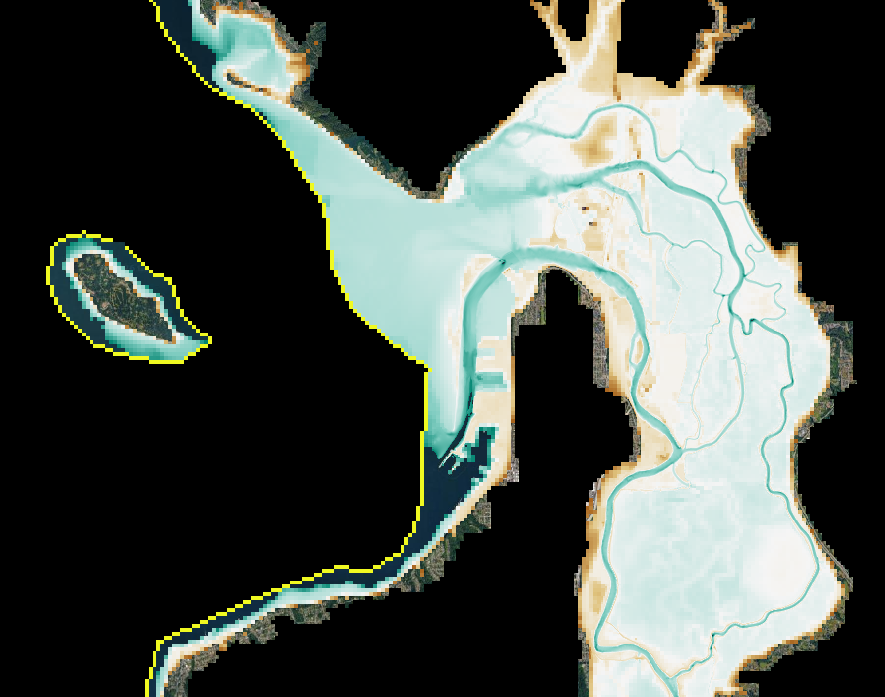

## Build Inputs

Note, I'm using a custom input template (included in files)

### Prep shared files, etc

In [26]:
import xarray as xr
import numpy as np
import os
import utm

parent_dir = '/home/cassandra/Snohomish/2026-05-14/'
template_file = parent_dir + 'sfincs_template.inp'

# Load discharge and water level data set
# I reformatted the wflow output, selecting only the discharge points I wanted
discharge  = xr.open_dataset(parent_dir + 'wflow.nc')
# Associated location array
da_loc_array = np.column_stack([discharge.x.values, discharge.y.values])

# Original formatting -- giant file though! Be ware!
waterlevel = xr.open_dataset('/media/cassandra/Expansion/Regional_ERA5_WlWaves_Snohomish.nc')
# Water level timestep needs manual loading...
minutes = waterlevel.time.values.astype(int)
time = np.datetime64('1940-01-01T00:00') + minutes.astype('timedelta64[m]')
# Location array for water levels
lat, lon = waterlevel.lat_wl.values, waterlevel.lon_wl.values
x, y, _, __ = utm.from_latlon(lat, lon)
wl_loc_array = np.column_stack([x, y])

# Make input files associated with the water level / discharge source locations
np.savetxt(parent_dir + "sfincs.src", da_loc_array, fmt="%.3f")
np.savetxt(parent_dir + "sfincs.bnd", wl_loc_array, fmt="%.3f")

### Method to generate each input file

1. discharge time series (src is shared)
2. water level time series (bnd is shared)
3. input file from template

In [27]:
def make_model(t0, tf, model_dir, DTMAPOUT='2592000'):
    # Discharge Input
    sda = discharge.sel(time=slice(t0, tf))
    Q = sda.discharge.values  # shape (T, L)
    # Convert time coordinates to elapsed seconds from t0
    time_seconds = (sda.time.values - t0) / np.timedelta64(1, 's')
    # Format and save
    out = np.column_stack([time_seconds, Q])
    fmt = ["%.1f"] + ["%.3f"] * Q.shape[1]
    np.savetxt(model_dir + "sfincs.dis", out, fmt=fmt)

    # Water Level Input
    swl = waterlevel.sel(time=slice(t0, tf))
    eta = swl.tide.values  # shape (T, L)
    # Convert time coordinates to elapsed seconds from t0
    time_seconds = (swl.time.values - t0) / np.timedelta64(1, 's')
    # Format and save
    out = np.column_stack([time_seconds, eta.T])
    fmt = ["%.1f"] + ["%.3f"] * eta.shape[0]
    np.savetxt(model_dir + "sfincs.bzs", out, fmt=fmt)

    # Create sfincs.inp from template
    input_template_file = open(template_file, 'r')
    input_template = input_template_file.read()
    tstart = str(t0)[:10].replace('-', '') + ' ' + str(t0)[11:].replace(':', '')
    tstop  = str(tf)[:10].replace('-', '') + ' ' + str(tf)[11:].replace(':', '')
    input_file_content = input_template.format(TSTART=tstart, 
                                               TSTOP=tstop, 
                                               TREF=tstart,
                                               DTMAPOUT=DTMAPOUT)
    input_file = open(model_dir + 'sfincs.inp', "w")
    input_file.write(input_file_content)
    input_file.close()

### Yearly inputs

In [28]:
# Buffer for spinup time. 1 week. 
buffer = np.timedelta64(7*24*60, 'm')

# For each WATER year... 
for year in np.arange(1942, 2024, 1):
    
    # Get start and stop timestamps
    # Water year for 2000 runs from 1999-10-01 through 2000-09-30 so...
    t0 = np.datetime64(str(year-1) + '-10-01T00:00') - buffer
    tf = np.datetime64(str(year)   + '-10-01T00:00')

    # Make model directory
    model_dir = parent_dir + str(year) + '/'
    if not os.path.exists(model_dir):
        os.mkdir(model_dir)

    # Make model input files
    make_model(t0, tf, model_dir)

### Make Benchmark

In [29]:
# Feb 2016 benchmark event
t0 = np.datetime64('2016-02-10T00:00')
tf = np.datetime64('2016-02-25T00:00')

model_dir = parent_dir + "benchmark" + '/'
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

make_model(t0, tf, model_dir, DTMAPOUT='1800')

## Read Benchmark

I simulated the benchmark on HYAK and wrote this brief script to SIMPLY downscale it, and make some comparison plots...

### Load and plot versus observations along channel

In [59]:
import utm
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt


In [60]:
# Load model output
his = xr.open_dataset(parent_dir + 'benchmark/sfincs_his.nc')

# Station names
obs_station_names = his.station_name.values.astype(str)
obs_station_names = np.array([n.replace(' ','') for n in obs_station_names])

# Timestep
t = his.time.values
dt = t[1] - t[0]

# Station data
obs_station_etas = his.point_zs.values.T

### Load Model and Observed Validation Data

#### Start with NOAA floodplain restoration study

In [61]:
# Paired model and observed time series go here
obs_etas = []
mod_etas = []

In [62]:
# NOAA pressure sensors from floodplain restoration study
sensor_name = 'MS2'
file_name = parent_dir + sensor_name + "_waterlevel.nc"

# Load the pressure sensor data
nc = xr.open_dataset(file_name)
obs_t = nc.datetime.values
obs_eta = nc.waterlevel.values

# Mask for ok times
tok = np.logical_and(obs_t >= t[0], obs_t <= t[-1])

# Interpolate onto model time step
obs_etas.append(np.interp(t.astype('datetime64[ms]').astype(float),
                 obs_t[tok].astype('datetime64[ms]').astype(float),
                 obs_eta[tok]))

# Load the model output at this sensor
this_sensor = np.where(obs_station_names == sensor_name)[0][0]
mod_etas.append(obs_station_etas[this_sensor])

#### Next, load USGS gage data

In [63]:
# USGS gage data. Using the gage data for 2016, which I stored in the benchmark folder...
mon_path = parent_dir + 'benchmark/12150800.txt'
sno_path = parent_dir + 'benchmark/12155500.txt'
# Use datum and units change
feet_to_meters = 0.3048
cubic_feet_to_meters = feet_to_meters**3
mon_datum =  17.05
sno_datum = - 6.43
# Switch from PST to UTM
time_zone_swap = np.timedelta64(8, 'h')
# Load Monroe gage
mon_df = pd.read_table(mon_path, comment='#', skiprows=[28])
mon_t =  mon_df['datetime'].values.astype('datetime64[s]') + time_zone_swap
mon_z = (mon_df['151245_00065'].values + mon_datum ) * feet_to_meters # note the datum
mon_q =  mon_df['151244_00060'].values * cubic_feet_to_meters
# Load Snohomish gage (stage only, no discharge)
sno_df = pd.read_table(sno_path, comment='#', skiprows=[27])
sno_t  = sno_df['datetime'].values.astype('datetime64[s]') + time_zone_swap
sno_z = (sno_df['151253_00065'].values + sno_datum ) * feet_to_meters # note the datum

# Interpolate onto model timestep and add to obs_eta
obs_etas.append(np.interp(t.astype('datetime64[ms]').astype(float),
                      sno_t.astype('datetime64[ms]').astype(float),
                      sno_z))
obs_etas.append(np.interp(t.astype('datetime64[ms]').astype(float),
                      mon_t.astype('datetime64[ms]').astype(float),
                      mon_z))

#### Load paired model output point using the along-channel points...

In [64]:
# Get gage locations
mon_lon, mon_lat = -122.051110, 47.833551
mon_x, mon_y, _, __ = utm.from_latlon(mon_lat, mon_lon)

sno_lon, sno_lat = -122.107231, 47.911877
sno_x, sno_y, _, __ = utm.from_latlon(sno_lat, sno_lon)

In [65]:
# Get mask for obs points in the channel
is_channel = np.array(['Snohomish-' in str(name) for name in his.station_name.values])

# Get x,y coordinates of channel obs points
sx, sy = his.station_x.values, his.station_y.values
cx, cy = sx[is_channel], sy[is_channel]

# Get closest channel point
sno_dist = np.sqrt((sno_x-cx)**2 + (sno_y-cy)**2)
sno_i = np.argmin(sno_dist)
mon_dist = np.sqrt((mon_x-cx)**2 + (mon_y-cy)**2)
mon_i = np.argmin(mon_dist)

# Get data from that obs point
mod_etas.append(his.point_zs[:,is_channel][:,sno_i].values)
mod_etas.append(his.point_zs[:,is_channel][:,mon_i].values)

### Plot model versus observed

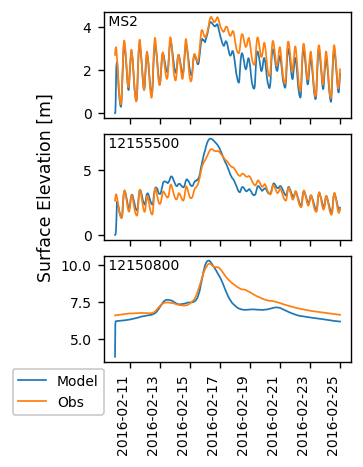

In [70]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(3,4), sharex=True, dpi=125)
for i, name in enumerate(['MS2', '12155500', '12150800']):
    axs[i].plot(t, mod_etas[i], label='Model', linewidth=1)
    axs[i].plot(t, obs_etas[i], label='Obs', linewidth=1)
    axs[i].set_title(' ' + name, fontsize=8, loc='left',y=1.0, pad=-8)
fig.autofmt_xdate(bottom=0.2, rotation=90, ha='right')
axs[1].set_ylabel("Surface Elevation [m]\n")
axs[-1].legend(bbox_to_anchor=(0.03, 0), framealpha=1, fontsize=8)
plt.tight_layout()
plt.subplots_adjust(hspace=0.15)
for a in axs:
    a.tick_params(labelsize=8)
fig.savefig(parent_dir + 'benchmark/channel_validation.png', dpi=150)
plt.show()

Recall:

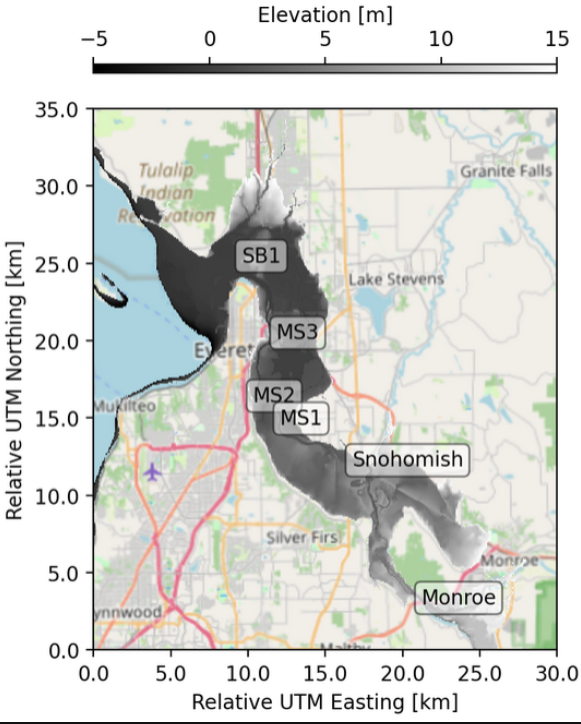

### Test tides

#### First, compute distance along the channel for the various channel observation points

In [73]:
from shapely.geometry import Point
import geopandas as gpd

## Using Snohomish channel linestring....
channel_file = parent_dir + 'snohomish.geojson'
chan = gpd.read_file(channel_file).geometry[0]
chan_x, chan_y = chan.xy

# Get along-path coordinate and distance for history filefrom shapely.geometry import Point
sta_dists = np.array([chan.project(Point(x,y)) for x,y in zip(sx, sy)])
c_dists = np.array([chan.project(Point(x,y)) for x,y in zip(cx, cy)])

#### Compute modeled and observed tidal components

In [77]:
%%capture cap 
# "Magic Command" to squash cell output

from utide import solve

# Get the modeled time series associated with the channel obs points
c_etas = obs_station_etas[is_channel]

# Compute coefficients along the path
path_coeffs = []
for eta in c_etas:
    path_coeffs.append(solve(t, eta, lat=48))

# Compute observed coefficients
obs_coeffs = []
obs_dists = []
for j, name in enumerate(['MS2', '12155500', '12150800']):
    sta_i = np.where(obs_station_names == name)[0][0]
    obs_coeffs.append(solve(t, obs_etas[j], lat=48))
    obs_dists.append(sta_dists[sta_i])
obs_dists = np.array(obs_dists)

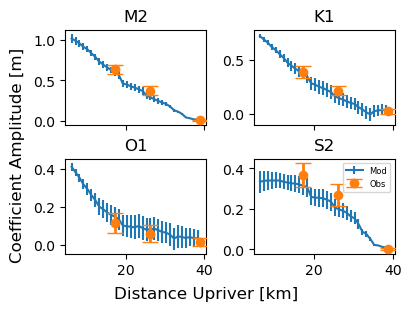

In [80]:
fig, axs = plt.subplots(nrows=2,ncols=2, figsize=(4,3), constrained_layout=True, sharex=True)
axs = axs.flatten()

# For each tidal component
for i, cn in enumerate(path_coeffs[0]['name'][:10][:4]):
    axs[i].set_title(cn)

    # Get that component at each location observed...
    obs_amps = []
    obs_amps_ci = []
    for obs_coeff in obs_coeffs:
        ai = np.where(obs_coeff['name'] == cn)[0]
        obs_amps.append(obs_coeff['A'][ai][0])
        obs_amps_ci.append(obs_coeff['A_ci'][ai][0])
    obs_amps = np.array(obs_amps)
    obs_amps_ci = np.array(obs_amps_ci)
        
    # ... and modeled
    mod_amps = []
    mod_amps_ci = []
    for mod_coeff in path_coeffs:
        j = np.where(mod_coeff['name'] == cn)
        mod_amps.append(mod_coeff['A'][j][0])
        mod_amps_ci.append(mod_coeff['A_ci'][j][0])
    mod_amps = np.array(mod_amps)
    mod_amps_ci = np.array(mod_amps_ci)
    
    axs[i].errorbar(c_dists/1000, mod_amps, yerr=mod_amps_ci, label='Mod')
    axs[i].errorbar(obs_dists/1000, obs_amps, yerr=obs_amps_ci, zorder=5,
                    fmt='o', linewidth=2, capsize=6, label='Obs')
    
axs[-1].legend(loc=1, fontsize=6)
fig.supxlabel("Distance Upriver [km]")
fig.supylabel("Coefficient Amplitude [m]")
plt.show()
fig.savefig(parent_dir + 'benchmark/tide_analysis.png', dpi=400)